### ARBOUET - CEMES-CNRS - 2024 
### test program for opimization using pytorch
### context : amplitude and phase shaping for electron beam shaping - active compensation of TEM aberrations

# NCG-Optimizer is a set of optimizer about nonlinear conjugate gradient in PyTorch.

https://github.com/RyunMi/NCG-Optimizer


In [1]:
import torch
import torch.optim as optim


import matplotlib.pyplot as plt
import ncg_optimizer as optim_ncg
import numpy as np
import torch.nn as nn
import torch.fft
import torch.nn.functional as F

def generate_phase_distribution_NCG_restricted(target_phase, target_amplitude, num_pixels, Niter, imin, imax,jmin,jmax, phase_distribution_ini):
    """
    AA - CNRS - 2024
    Generic routine for use with NGC nonlinear optimizer
    possibility of using several optimization strategies
    more information : https://github.com/RyunMi/NCG-Optimizer
    both the algorithm and line search strategy should be properly chosen for specific purposes
    """
    # Target complex field in the focal plane
    target_complex_field = target_amplitude * torch.exp(1j * target_phase)

    # Initialize phase distribution as a trainable parameter
    phase_distribution = torch.nn.Parameter(phase_distribution_ini.clone(), requires_grad=True)
    # Define the loss function
    loss_function = nn.MSELoss()

    # Create optimizer - different options possibles (I wrote the outcome of basic tests, some of them do not work but no efforts to find the problem made yet)

#    optimizer = optim_ncg.BASIC(  [phase_distribution], method='PRP',     line_search='Armijo',   c1=1e-4,   c2=0.9,  lr=1,   rho=0.5  )    # Nan....
#    optimizer = optim_ncg.BASIC(  [phase_distribution], method = 'HS-DY', line_search = 'Armijo', c1 = 1e-4, c2 = 0.9, lr = 1, rho = 0.5 )   # OK
#    optimizer = optim_ncg.BASIC(  [phase_distribution], method = 'HZ',    line_search = 'Strong_Wolfe', c1 = 1e-4, c2 = 0.9, lr = 0.2, max_ls = 25)  # pb backward ....
    optimizer = optim_ncg.BASIC(  [phase_distribution], method = 'LS',    line_search = 'Armijo',       c1 = 1e-4, c2 = 0.9, lr = 1, rho = 0.5)   # OK

    def closure():
        optimizer.zero_grad()

        # Calculate current SLM field
        phase_field = torch.exp(1j * phase_distribution)
        
        # Forward propagation through lens to focal plane
        focal_plane_field = torch.fft.fftn(phase_field)

        # Normalize the amplitude to the maximum of the image
       # max_amplitude = torch.max(torch.abs(focal_plane_field))
       # normalized_amplitude = torch.abs(focal_plane_field) / max_amplitude
        
        # Normalize the target amplitude to the maximum of the image
       # max_target_amplitude = torch.max(torch.abs(target_amplitude))
       # normalized_target_amplitude = torch.abs(target_amplitude) / max_target_amplitude

        # Compute loss between actual and target complex field
        #amplitude_loss = loss_function(torch.abs(focal_plane_field[imin:imax, jmin : jmax]), target_amplitude[imin:imax, jmin : jmax])
        #phase_loss = loss_function(torch.angle(focal_plane_field[imin:imax, jmin : jmax]), target_phase[imin:imax, jmin : jmax])
        #loss = amplitude_loss + phase_loss
        d=2
        loss = loss_function(10**d * (
            1-torch.sum(torch.sqrt(torch.abs(focal_plane_field[imin:imax, jmin : jmax]) * target_amplitude[imin:imax, jmin : jmax]) * 
                        torch.cos(torch.angle(target_phase[imin:imax, jmin : jmax]) - torch.angle(focal_plane_field[imin:imax, jmin : jmax]))))**2,
                            torch.zeros(target_amplitude[imin:imax, jmin : jmax].shape) )

        # Compute gradient of the loss
        loss.backward()

        return loss

    # Main optimization loop
    for i in range(Niter):
        
        loss = optimizer.step(closure)

        # Bring back phase distribution to [0, 2*pi]
        with torch.no_grad():
            phase_distribution.data = phase_distribution.data#% (2 * torch.pi)

        if (i + 1) % 500 == 0:
            print("Iteration {}: Loss = {:.6f}".format(i + 1, loss.item()))

    return phase_distribution.data


def generate_phase_distribution_CG_restricted(target_phase, target_amplitude, num_pixels, Niter, imin, imax,jmin,jmax):
    """
    AA - CNRS - 2024
    Conjugate gradients "home-made" (AA, probably come with errors....)
    to be considered only as a starting point ....
    """
    # Target complex field in focal plane
    target_complex_field = target_amplitude * torch.exp(1j * target_phase)

     # Define loss function
    loss_function = torch.nn.MSELoss()
 
    # Initialize phase distribution as trainable parameter
    phase_distribution = torch.nn.Parameter(torch.rand(num_pixels, num_pixels) * 2 * torch.pi)

    # Initialize conjugate direction and previous gradient
    conjugate_direction = None
    grad_prev = None
    
    # Main optimization loop
    for i in range(Niter):
        # Calculate current SLM field
        phase_field = torch.exp(1j * phase_distribution)
        
        # Forward propagation through lens to focal plane
        focal_plane_field = torch.fft.fftn(phase_field)
        
        # Compute loss between actual and target complex field
        #loss = torch.mean(torch.abs(torch.abs(focal_plane_field) - target_amplitude)**2) + \
        #       torch.mean(torch.abs(torch.angle(focal_plane_field) - target_phase)**2)
        
        intens_util = torch.sum(torch.abs(focal_plane_field[imin:imax, jmin : jmax]))
        intens_tot =  torch.sum(torch.abs(focal_plane_field))

        loss = loss_function(torch.abs(focal_plane_field[imin:imax, jmin : jmax]), torch.abs(target_amplitude[imin:imax, jmin : jmax])) + \
               loss_function(torch.angle(focal_plane_field[imin:imax, jmin : jmax]), target_phase[imin:imax, jmin : jmax]) 
        
        loss = loss  * intens_util / intens_tot
        # Compute gradient of the loss
        loss.backward()
        
        # Compute conjugate direction using the Polak-Ribière formula
        if i == 0:
            conjugate_direction = - phase_distribution.grad
        else:
            beta = torch.sum(phase_distribution.grad * (phase_distribution.grad - grad_prev)) / torch.sum(grad_prev * grad_prev)
            conjugate_direction = - phase_distribution.grad + beta * conjugate_direction
            
        grad_prev = phase_distribution.grad.clone()
        
        # Update parameters along the conjugate direction with a suitable step size
        with torch.no_grad():
            step_size = torch.norm(phase_distribution.grad) ** 2 / torch.real(torch.sum(conjugate_direction * torch.fft.ifft2(torch.fft.fft2(conjugate_direction))))
            phase_distribution.data += step_size * conjugate_direction
        
        # Reset gradient
        phase_distribution.grad.zero_()
        
        # Bring back phase distribution to [0, 2*pi]
        phase_distribution.data = phase_distribution.data % (2 * torch.pi)
        
        if (i + 1) % 100 == 0:
            print(f"Iteration {i + 1}: Loss = {loss.item():.6f}")
    
    return phase_distribution.data



def generate_phase_distribution_restricted(target_phase, target_amplitude, num_pixels, Niter, imin, imax, jmin, jmax, phase_distribution_ini):
    """
    AA - CNRS - 2024
    Stochastic Gradient Descent optimization
    applied on a sub-region of target image defined by (imin, imax, jmin, jmax)
    initial phase distribution : phase_distribution_ini
    possibility of rerunning optimization from the outcome of a previous calculation or performing another one after initialization of phase_distribution_ini
    """
    # Target complex field in focal plane
    target_complex_field = target_amplitude * torch.exp(1j * target_phase)
 
    # Initialize phase distribution as trainable parameter
    phase_distribution = torch.nn.Parameter(phase_distribution_ini.clone(), requires_grad=True)

    # Define optimizer and loss function
    optimizer = optim.SGD([phase_distribution], lr=0.01)  # , momentum=0.9)
    loss_function = torch.nn.MSELoss()
    
    # List to store the loss values
    loss_values = []
    number_selected_pixels = (imax - imin) * (jmax - jmin)

    # Main optimization loop
    for i in range(Niter):
        optimizer.zero_grad()
        
        phase_field = torch.exp(1j * phase_distribution)
        
        # Forward propagation through lens to focal plane
        focal_plane_field = torch.fft.fftn(phase_field)
        
        # Intensity in selected region and total
        intens_util = torch.sum(torch.abs(focal_plane_field[imin:imax, jmin:jmax]))
        intens_tot = torch.sum(torch.abs(focal_plane_field))
        intens_outside = intens_tot - intens_util
        # Looking for maximum of amplitude and normalizing ....
        Imax_target = torch.max(torch.abs(focal_plane_field))
        Imax_optim = torch.max(torch.abs(target_amplitude))

        # Compute loss between actual and target complex field
                
        loss = loss_function(torch.abs(focal_plane_field[imin:imax, jmin:jmax]), torch.abs(target_amplitude[imin:imax, jmin:jmax])) + \
               loss_function(torch.angle(focal_plane_field[imin:imax, jmin:jmax]), target_phase[imin:imax, jmin:jmax]) # +\
               #- 10 * (intens_util / number_selected_pixels)   # + \
               #10 * intens_outside/(num_pixels**2 - number_selected_pixels)
        
        # Backpropagation and optimization step
        loss.backward()
        optimizer.step()
        
        # Store the current loss value
        loss_values.append(loss.item())
        
        # Bring back phase distribution to [0, 2*pi]
        with torch.no_grad():
            phase_distribution.data = phase_distribution.data % (2 * torch.pi)
        
        if (i+1) % 500 == 0:
            print("Iteration {}: Loss = {:.6f}".format(i+1, loss.item()))
    
    # Plot the loss values
    plt.figure(figsize=(10, 6))
    plt.plot(loss_values, label='Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss Convergence')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return phase_distribution.data

def generate_phase_distribution(target_phase, target_amplitude, num_pixels, Niter, phase_distribution_ini):
    """
    AA - CNRS - 2024
    Stochastic Gradient Descent optimization
    applied on entire target image
    initial phase distribution : phase_distribution_ini
    possibility of rerunning optimization from the outcome of a previous calculation or performing another one after initialization of phase_distribution_ini
    """
    # Target complex field in focal plane
    target_complex_field = target_amplitude * torch.exp(1j * target_phase)
 
    # Initialize phase distribution as trainable parameter
    phase_distribution = phase_distribution_ini

    # Define optimizer and loss function
    optimizer =  optim.SGD([phase_distribution], lr=0.01)#, momentum=0.9)
    loss_function = torch.nn.MSELoss()
        
    # Main optimization loop
    
    for i in range(Niter):
        optimizer.zero_grad()
        
        phase_field = torch.exp(1j * phase_distribution)
        
        # Forward propagation through lens to focal plane
        focal_plane_field = torch.fft.fftn(phase_field)
        
        # Compute loss between actual and target complex field
        
        loss = loss_function(torch.abs(focal_plane_field), torch.abs(target_amplitude)) + \
               loss_function(torch.angle(focal_plane_field), target_phase) 
        
        #loss = loss_function(torch.abs(focal_plane_field), target_amplitude) + \
        #       loss_function(torch.ang(focal_plane_field), torch.real(target_complex_field)) + \
        #       loss_function(torch.imag(focal_plane_field), torch.imag(target_complex_field))
        

        # Backpropagation and optimization step
        loss.backward()
        optimizer.step()
        
        # Bring back phase distribution to [0, 2*pi]
        phase_distribution.data = (phase_distribution.data ) % (2 * torch.pi)
        
        if (i+1) % 100 == 0:
            print("Iteration {}: Loss = {:.6f}".format(i+1, loss.item()))
    
    return phase_distribution.data


In [2]:
def create_gaussian_spot(shape, center, sigma):
    """
    Create a Gaussian spot centered at `center` with standard deviation `sigma` in a tensor of given `shape`.
    
    Args:
    - shape (tuple): The shape of the output tensor (Npix, Npix).
    - center (tuple): The coordinates of the center of the Gaussian spot (i0, j0).
    - sigma (float): The standard deviation of the Gaussian spot.
    
    Returns:
    - torch.Tensor: A tensor with a Gaussian spot.
    """
    Npix_x, Npix_y = shape
    i0, j0 = center

    # Create coordinate grids
    x = torch.arange(Npix_x).float()
    y = torch.arange(Npix_y).float()
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Calculate the Gaussian spot
    gauss = torch.exp(-((X - i0) ** 2 + (Y - j0) ** 2) / (2 * sigma ** 2))
    
    return gauss

def create_vortex_spot(shape, center, order):
    """
    Create a vortex at `center` of order `order` in a tensor of given `shape`.
    
    Args:
    - shape (tuple): The shape of the output tensor (Npix, Npix).
    - center (tuple): The coordinates of the center of the vortex (i0, j0).
    - order (integer): The order of the vortex.
    
    Returns:
    - torch.Tensor: A tensor with a Gaussian spot.
    """
    Npix_x, Npix_y = shape
    i0, j0 = center

    # Create coordinate grids
    x = torch.arange(Npix_x).float()
    y = torch.arange(Npix_y).float()
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Calculate the Gaussian spot
    R = torch.sqrt(( X -i0) **2 + (Y - j0) **2)  # Radial distance
    theta = torch.arctan2(Y - j0, X - i0)  # Angle in radians

    vortex = order * theta 
    vortex = vortex % (2 * torch.pi)
    return vortex



def create_vortex_spot_smooth(shape, center, order, sigma=1.0):
    """
    Create a vortex at `center` of order `order` in a tensor of given `shape`,
    with a smoothing function to get rid of discontinuities.
    
    Args:
    - shape (tuple): The shape of the output tensor (Npix, Npix).
    - center (tuple): The coordinates of the center of the vortex (i0, j0).
    - order (integer): The order of the vortex.
    - sigma (float): The standard deviation of the Gaussian kernel for smoothing.
    
    Returns:
    - torch.Tensor: A tensor with a smoothed phase distribution for the vortex.
    """
    Npix_x, Npix_y = shape
    i0, j0 = center

    # Create coordinate grids
    x = torch.arange(Npix_x).float()
    y = torch.arange(Npix_y).float()
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Calculate the phase distribution
    theta = torch.atan2(Y - j0, X - i0)  # Angle in radians
    vortex = order * theta

    # Define Gaussian kernel for smoothing
    kernel_size = int(6 * sigma + 1)  # Kernel size
    x = torch.linspace(-3 * sigma, 3 * sigma, kernel_size)
    gauss_kernel_1d = torch.exp(-0.5 * (x / sigma)**2)
    gauss_kernel_1d /= gauss_kernel_1d.sum()

    # Convolve the phase with Gaussian kernel
    gauss_kernel_2d = gauss_kernel_1d[:, None] * gauss_kernel_1d[None, :]
    gauss_kernel_2d = gauss_kernel_2d.to(vortex.device)

    vortex_smoothed = F.conv2d(vortex.unsqueeze(0).unsqueeze(0), gauss_kernel_2d.unsqueeze(0).unsqueeze(0), padding=kernel_size//2)
    
    return vortex_smoothed.squeeze()

C:\Users\weber\.conda\envs\pymo5_dev\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4319.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


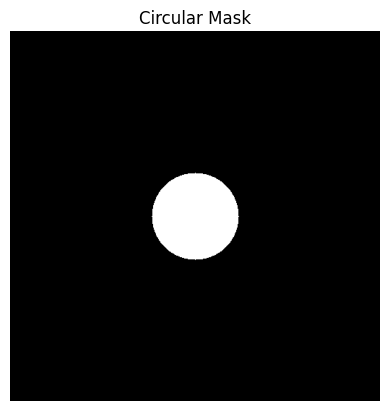

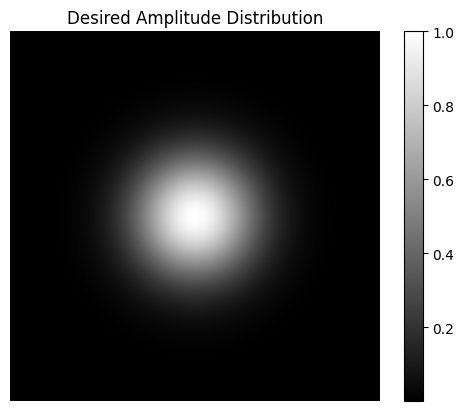

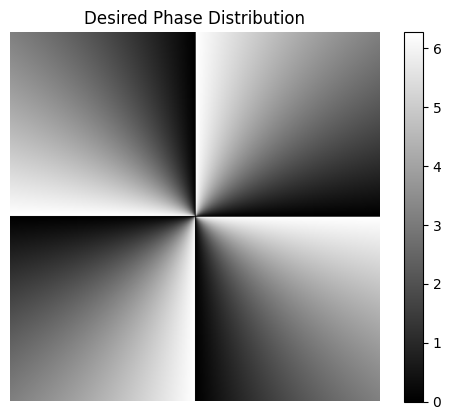

In [3]:
# Parameters
Npix = 512  # Size of the image
radius = 60  # Radius of the circular region
center = (Npix // 2, Npix // 2)  # Center of the circular region

# Create a grid of coordinates
x = torch.arange(Npix).float()
y = torch.arange(Npix).float()
X, Y = torch.meshgrid(x, y)

# Compute distances from the center
distances = torch.sqrt((X - center[0])**2 + (Y - center[1])**2)

# Create a mask for the circular region
circular_mask = distances <= radius

# Function to create a circular mask
def create_circle_mask(shape, radius, center):
    x = torch.arange(shape[0]).unsqueeze(1)
    y = torch.arange(shape[1]).unsqueeze(0)
    mask = ((x - center[0]) ** 2 + (y - center[1]) ** 2) <= radius ** 2
    return mask

# Define desired values for phase and amplitude
phase = 0.6
desired = torch.ones(Npix, Npix) * torch.pi / 4  

#target_amplitude = torch.where(create_circle_mask((Npix, Npix), radius, center), torch.full_like(desired, 1.0), torch.zeros(Npix, Npix))  
#target_phase     = torch.where(create_circle_mask((Npix, Npix), radius, center), torch.full_like(desired, torch.pi), torch.zeros(Npix, Npix))  

i0 = int(Npix/2)
j0 = int(Npix/2)
sigma = 60
vortex_order = 4
target_amplitude = create_gaussian_spot((Npix, Npix) , (i0, j0), sigma )
target_phase     = create_vortex_spot((Npix, Npix) , (i0, j0), vortex_order )
#target_phase     = create_vortex_spot_smooth((Npix, Npix) , (i0, j0), vortex_order , sigma = 20)

# Plot the circular mask (optional)
plt.imshow(circular_mask, cmap='gray')
plt.title('Circular Mask')
plt.axis('off')
plt.show()

# Plot the desired amplitude distribution (optional)
plt.imshow(target_amplitude, cmap='gray')
plt.title('Desired Amplitude Distribution')
plt.axis('off')
plt.colorbar()
plt.show()

# Plot the desired phase distribution (optional)
plt.imshow(target_phase, cmap='gray')
plt.title('Desired Phase Distribution')
plt.axis('off')
plt.colorbar()
plt.show()

def plot_area(target_amplitude, imin, imax, jmin, jmax):
    plt.imshow(target_amplitude, cmap='gray')
    plt.axvline(x=jmin, color='r', linestyle='--')
    plt.axvline(x=jmax, color='r', linestyle='--')
    plt.axhline(y=imin, color='r', linestyle='--')
    plt.axhline(y=imax, color='r', linestyle='--')
    plt.title('Considered Area')
    plt.colorbar()
    plt.show()

In [4]:
import matplotlib.pyplot as plt

def plot_amplitude_and_phase(target_amplitude, target_phase, computed_phase,vminamp,vmaxamp):
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # Plot target amplitude
    im1 = axs[0, 0].imshow(target_amplitude, cmap='hot', vmin = 0, vmax = 1.5)
    axs[0, 0].set_title('Target Amplitude')
    axs[0, 0].axis('off')
    fig.colorbar(im1, ax=axs[0, 0])

    # Plot target phase
    im2 = axs[0, 1].imshow(target_phase, cmap='hot' , vmin = 0, vmax = 2*np.pi )
    axs[0, 1].set_title('Target Phase')
    axs[0, 1].axis('off')
    fig.colorbar(im2, ax=axs[0, 1])

    # Plot computed amplitude
    computed_amplitude = torch.abs(torch.fft.fftn(torch.exp(1j * computed_phase)))
    im3 = axs[1, 0].imshow(computed_amplitude, cmap='hot', vmin = vminamp, vmax = vmaxamp)
    axs[1, 0].set_title('Computed Amplitude')
    axs[1, 0].axis('off')
    fig.colorbar(im3, ax=axs[1, 0])

    # Plot computed phase
    computed_phase_angle = torch.angle(torch.fft.fftn(torch.exp(1j * computed_phase)))
    im4 = axs[1, 1].imshow(computed_phase_angle, cmap='hot' , vmin = 0, vmax = 2*np.pi )
    axs[1, 1].set_title('Computed Phase')
    axs[1, 1].axis('off')
    fig.colorbar(im4, ax=axs[1, 1])

    plt.tight_layout()
    plt.show()

# INITIALIZATION

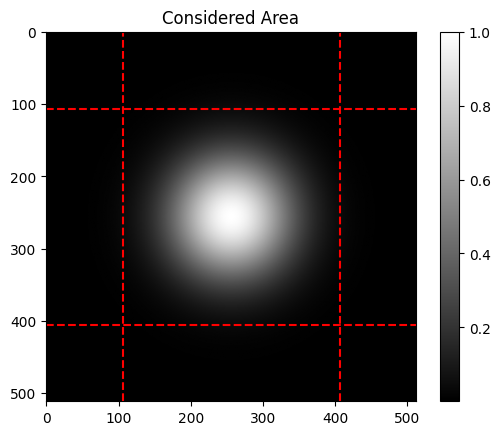

In [5]:
Deltaij = 300
imin = np.max( (i0 - int(0.5*Deltaij) , 0) )
imax = np.min( (i0 + int(0.5*Deltaij), Npix - 1))
jmin = np.max( (j0 - int(0.5*Deltaij), 0))
jmax = np.min((j0 + int(0.5*Deltaij) , Npix - 1))

plot_area(target_amplitude, imin, imax, jmin, jmax)

In [6]:
# Initialize phase distribution as trainable parameter
phase_distribution_start = torch.nn.Parameter(torch.rand(Npix, Npix) * 2 * torch.pi)

In [7]:
#phase_distribution_start.data = phase_distribution

In [8]:
Niter = 1000
#phase_distribution = generate_phase_distribution_restricted(target_phase, target_amplitude, Npix, Niter,imin,imax,jmin,jmax, phase_distribution_start)
phase_distribution = generate_phase_distribution_CG_restricted(target_phase, target_amplitude, Npix, Niter,imin,imax,jmin,jmax, phase_distribution_start)

TypeError: generate_phase_distribution_CG_restricted() takes 8 positional arguments but 9 were given

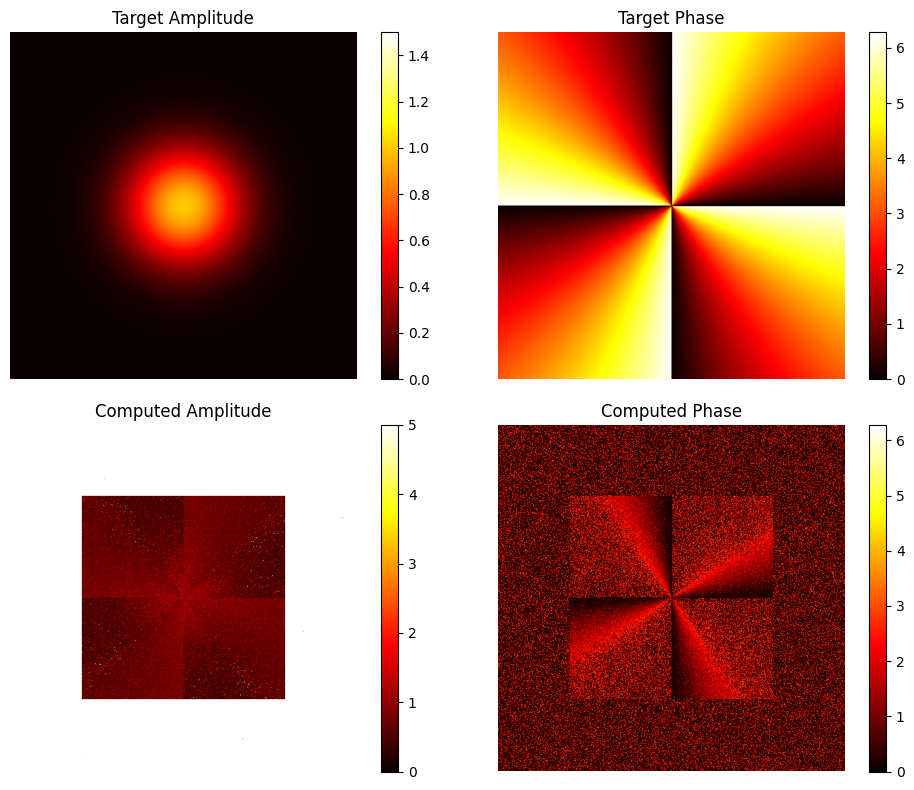

In [24]:
# Plot target amplitude and phase alongside computed amplitude and phase
plot_amplitude_and_phase(target_amplitude, target_phase, phase_distribution, 0 ,5)

# Analyzing how much intensity is actually in the region of interest

In [128]:
ratio = (imax - imin) * (jmax - jmin) / Npix**2
phase_field = torch.exp(1j * phase_distribution)
        
# Forward propagation through lens to focal plane
focal_plane_field = torch.fft.fftn(phase_field)

# Intensity in selected region and total
intens_util = torch.sum(torch.abs(focal_plane_field[imin:imax, jmin:jmax])**2)
intens_tot  = torch.sum(torch.abs(focal_plane_field)**2)
ratio_intens = (intens_util.data/intens_tot).item()

print('')
print('Ratio of Region Of Interest to total surface :', ratio*100,' %')
print('Ratio of intensities in Region Of Interest to total intensity :', ratio_intens*100,' %')


Ratio of Region Of Interest to total surface : 34.332275390625  %
Ratio of intensities in Region Of Interest to total intensity : 34.493350982666016  %


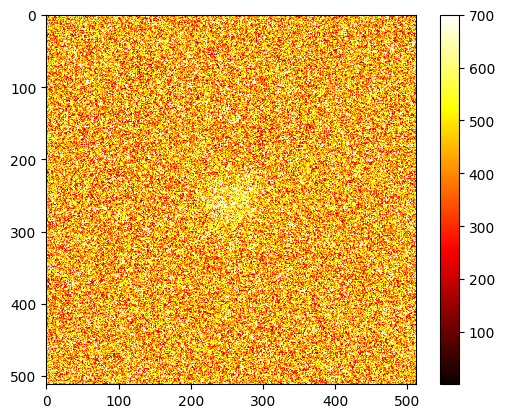

In [135]:
plt.imshow(torch.abs(torch.fft.fftn(torch.exp(1j * phase_distribution))), cmap='hot', vmax = 700)
plt.colorbar()


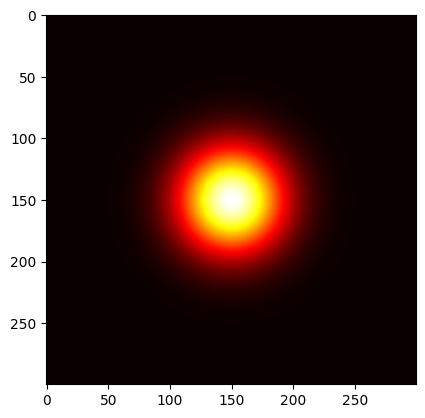

In [129]:
plt.imshow(target_amplitude[imin:imax, jmin : jmax] ,  cmap='hot') 